## Dataset: MNIST

- **MNIST**: 28×28 grayscale digits (fast, good for debugging ideas)



In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from dataclasses import dataclass

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as T
from tqdm.auto import tqdm

@dataclass
class CFG:
    dataset: str = "mnist"   # "mnist"
    data_dir: str = "./data"
    batch_size: int = 128    # chunk of data to be fed to the model each epoch
    num_workers: int = 2     # number of workers fetching the dataset
    val_frac: float = 0.1    # fraction of the dataset for validation

    epochs: int = 15         # number of training epochs
    lr: float = 1e-3         # learning rate
    weight_decay: float = 5e-4
    seed: int = 42

    quick_run: bool = False  # set true to run a quick smoke test
    quick_train_size: int = 8000 # set size of the dataset used for smoketest

cfg = CFG()

def seed_everything(seed=1337):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True  # speed
    torch.backends.cudnn.deterministic = False

seed_everything(cfg.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print(cfg)


Device: cpu
CFG(dataset='mnist', data_dir='./data', batch_size=128, num_workers=2, val_frac=0.1, epochs=15, lr=0.001, weight_decay=0.0005, seed=42, quick_run=False, quick_train_size=8000)


c:\Users\sungs\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load the data
- normalization (always)
- mild augmentation for CIFAR-10 (random crop + flip)

Normalization stabilizes training, while augmentation is tipically introduced to reduce overfitting and improve generalization.


In [4]:
def get_dataset(cfg: CFG):
    name = cfg.dataset.lower()
    if name == "mnist":
        num_classes = 10
        in_channels = 1
        class_names = [str(i) for i in range(10)]
        image_shape = (1, 28, 28)

        tf_train = T.Compose([
            T.ToTensor(),
            T.Normalize((0.1307,), (0.3081,))
        ])
        tf_test = tf_train

        train_full = torchvision.datasets.MNIST(cfg.data_dir, train=True, download=True, transform=tf_train)
        test = torchvision.datasets.MNIST(cfg.data_dir, train=False, download=True, transform=tf_test)

        denorm = lambda x: (x * 0.3081 + 0.1307).clamp(0, 1)

    elif name == "cifar10":
        num_classes = 10
        in_channels = 3
        class_names = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]
        image_shape = (3, 32, 32)

        mean = (0.4914, 0.4822, 0.4465)
        std  = (0.2470, 0.2435, 0.2616)

        tf_train = T.Compose([
            T.RandomCrop(32, padding=4),
            T.RandomHorizontalFlip(),
            T.ToTensor(),
            T.Normalize(mean, std),
        ])
        tf_test = T.Compose([
            T.ToTensor(),
            T.Normalize(mean, std),
        ])

        train_full = torchvision.datasets.CIFAR10(cfg.data_dir, train=True, download=True, transform=tf_train)
        test = torchvision.datasets.CIFAR10(cfg.data_dir, train=False, download=True, transform=tf_test)

        def denorm(x):
            mean_t = torch.tensor(mean, device=x.device).view(1,3,1,1)
            std_t  = torch.tensor(std,  device=x.device).view(1,3,1,1)
            return (x * std_t + mean_t).clamp(0, 1)

    else:
        raise ValueError("cfg.dataset must be 'mnist' or 'cifar10'")

    return train_full, test, num_classes, in_channels, class_names, image_shape, denorm

train_full, testset, K, C, class_names, image_shape, denorm = get_dataset(cfg)

# Optional quick run for smoke test
if cfg.quick_run:
    idxs = torch.randperm(len(train_full))[:cfg.quick_train_size].tolist()
    train_full = torch.utils.data.Subset(train_full, idxs)

n_total = len(train_full)
n_val = int(cfg.val_frac * n_total)
n_train = n_total - n_val

trainset, valset = random_split(
    train_full, [n_train, n_val],
    generator=torch.Generator().manual_seed(cfg.seed)
)

train_loader = DataLoader(trainset, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=cfg.num_workers, pin_memory=True)
val_loader   = DataLoader(valset, batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True)
test_loader  = DataLoader(testset, batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True)

print("Train/Val/Test sizes:", len(trainset), len(valset), len(testset))
print("Classes:", K, "| In channels:", C, "| Shape:", image_shape)


Train/Val/Test sizes: 54000 6000 10000
Classes: 10 | In channels: 1 | Shape: (1, 28, 28)


## EDA / diagnostics
analyzed class balance, sample images and perform some basic sanity checks on shapes and ranges for the images.


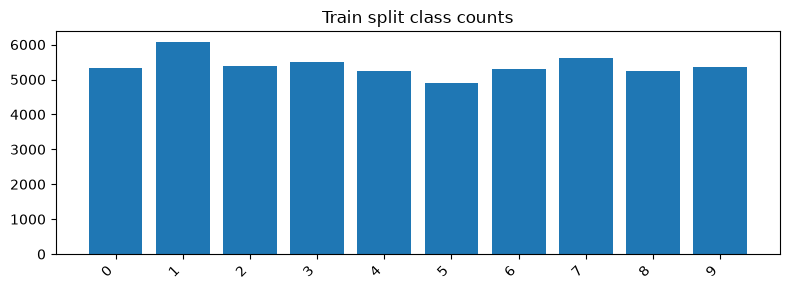

Min/Max class count: 4903 6076


In [5]:
def get_labels_from_subset(subset):
    if isinstance(subset, torch.utils.data.Subset):
        ds = subset.dataset
        idxs = subset.indices
        labels = []
        for i in idxs:
            _, y = ds[i]
            labels.append(int(y))
        return np.array(labels)
    else:
        return np.array([int(subset[i][1]) for i in range(len(subset))])

train_labels = get_labels_from_subset(trainset)
counts = np.bincount(train_labels, minlength=K)

plt.figure(figsize=(8,3))
plt.bar(range(K), counts)
plt.xticks(range(K), class_names, rotation=45, ha="right")
plt.title("Train split class counts")
plt.tight_layout()
plt.show()

print("Min/Max class count:", counts.min(), counts.max())


### Visual inspection
Visually check whether labels look plausible, normalization isn't broken and transforms for augmentation are implemented correctly.



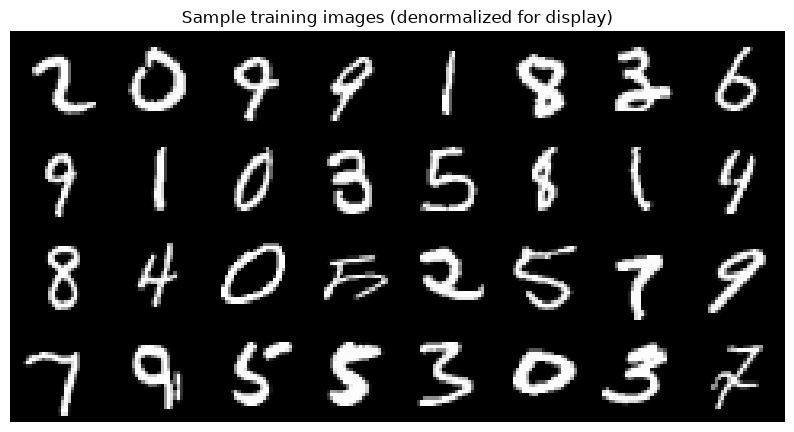

Sample labels: ['2', '0', '9', '9', '1', '8', '3', '6', '9', '1', '0', '3', '5', '8', '1', '4']
Batch tensor shape: torch.Size([128, 1, 28, 28])
Batch min/max: -0.4242129623889923 2.821486711502075


In [6]:
xb, yb = next(iter(train_loader))
xb_vis = xb[:32].to(device)

# denormalize for viewing
xb_vis = denorm(xb_vis)

grid = torchvision.utils.make_grid(xb_vis.cpu(), nrow=8)
plt.figure(figsize=(10,6))
plt.imshow(grid.permute(1,2,0).numpy())
plt.axis("off")
plt.title("Sample training images (denormalized for display)")
plt.show()

print("Sample labels:", [class_names[int(i)] for i in yb[:16].tolist()])
print("Batch tensor shape:", xb.shape)
print("Batch min/max:", xb.min().item(), xb.max().item())


## Traditional Classification model: Baseline CNN



In [7]:
#Model Architecture
class BaselineCNN(nn.Module):
    def __init__(self, in_channels: int, num_classes: int, width: int = 64):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, width, 3, padding=1),
            nn.BatchNorm2d(width),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(width, width*2, 3, padding=1),
            nn.BatchNorm2d(width*2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(width*2, width*4, 3, padding=1),
            nn.BatchNorm2d(width*4),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(width*4, width*4),
            nn.ReLU(inplace=True),
            nn.Linear(width*4, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)  # logits

model = BaselineCNN(C, K).to(device)
print(model) # check model architecture


BaselineCNN(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): AdaptiveAvgPool2d(output_size=1)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=256, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (

## Training utilities
Track Loss and accuracy


In [8]:
@torch.no_grad()
def accuracy_from_logits(logits, y):
    pred = logits.argmax(dim=1)
    return (pred == y).float().mean().item()

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, total_acc, n = 0.0, 0.0, 0

    for xb, yb in tqdm(loader, desc="train", leave=False):
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        loss.backward()
        optimizer.step()

        bs = xb.size(0)
        total_loss += loss.item() * bs
        total_acc  += accuracy_from_logits(logits, yb) * bs
        n += bs

    return total_loss / n, total_acc / n

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, total_acc, n = 0.0, 0.0, 0

    for xb, yb in tqdm(loader, desc="eval", leave=False):
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)

        bs = xb.size(0)
        total_loss += loss.item() * bs
        total_acc  += accuracy_from_logits(logits, yb) * bs
        n += bs

    return total_loss / n, total_acc / n

def predict_proba(model, loader):
    """Returns probs [N,K], y [N] for downstream analysis."""
    model.eval()
    probs_list, y_list = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            logits = model(xb)
            probs = F.softmax(logits, dim=1).cpu()
            probs_list.append(probs)
            y_list.append(yb)
    return torch.cat(probs_list, dim=0), torch.cat(y_list, dim=0)


## Run Training on the baseline

In [9]:
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

history = []
best_val_acc = -1.0
best_state = None

for epoch in range(cfg.epochs):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer)
    va_loss, va_acc = evaluate(model, val_loader)

    history.append((epoch, tr_loss, tr_acc, va_loss, va_acc))
    print(f"epoch={epoch:02d}  train_loss={tr_loss:.4f} train_acc={tr_acc:.4f}  val_loss={va_loss:.4f} val_acc={va_acc:.4f}")

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
te_loss, te_acc = evaluate(model, test_loader)
print(f"\nBest val_acc={best_val_acc:.4f} | Test acc={te_acc:.4f} | Test loss={te_loss:.4f}")


epoch=00  train_loss=0.2706 train_acc=0.9235  val_loss=0.7464 val_acc=0.7490


epoch=01  train_loss=0.0623 train_acc=0.9815  val_loss=0.2416 val_acc=0.9218


epoch=02  train_loss=0.0428 train_acc=0.9871  val_loss=0.1523 val_acc=0.9535


epoch=03  train_loss=0.0328 train_acc=0.9901  val_loss=0.3870 val_acc=0.8950


epoch=04  train_loss=0.0264 train_acc=0.9914  val_loss=0.0525 val_acc=0.9833


...

epoch=11  train_loss=0.0135 train_acc=0.9954  val_loss=0.0524 val_acc=0.9850


epoch=12  train_loss=0.0112 train_acc=0.9961  val_loss=0.0646 val_acc=0.9797


epoch=13  train_loss=0.0081 train_acc=0.9972  val_loss=0.1501 val_acc=0.9638


epoch=14  train_loss=0.0082 train_acc=0.9973  val_loss=0.0504 val_acc=0.9850



Best val_acc=0.9892 | Test acc=0.9886 | Test loss=0.0355


### Learning curves
Plots of the evolution of the metrics can help diagnose underfitting (both accuracies low), overfitting (train >> val), and/or instabilities (loss spikes).


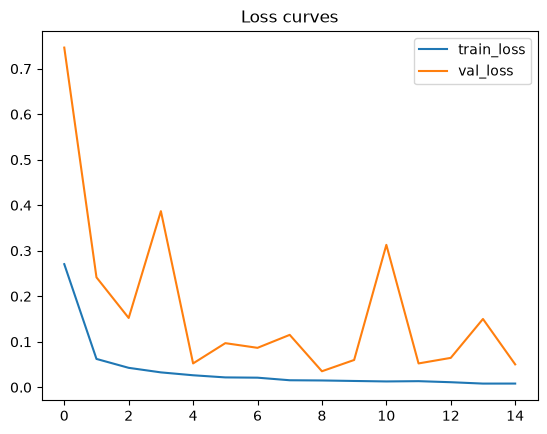

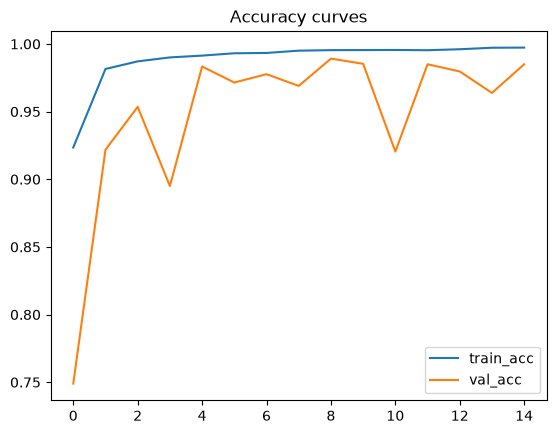

In [10]:
hist = np.array(history)
epochs = hist[:,0]
tr_loss, tr_acc, va_loss, va_acc = hist[:,1], hist[:,2], hist[:,3], hist[:,4]

plt.figure()
plt.plot(epochs, tr_loss, label="train_loss")
plt.plot(epochs, va_loss, label="val_loss")
plt.legend()
plt.title("Loss curves")
plt.show()

plt.figure()
plt.plot(epochs, tr_acc, label="train_acc")
plt.plot(epochs, va_acc, label="val_acc")
plt.legend()
plt.title("Accuracy curves")
plt.show()


## Investigate with the trained baseline
- confusion matrix
- confidence distribution
- most confident mistakes
- a grid of misclassified examples


In [12]:
probs_test, y_test = predict_proba(model, test_loader)
conf, pred = probs_test.max(dim=1)
correct = (pred == y_test)

print("Test accuracy (recomputed):", correct.float().mean().item())
print("Mean confidence (correct):", conf[correct].mean().item())
print("Mean confidence (wrong):  ", conf[~correct].mean().item())

# Show top-10 most confident wrong predictions
wrong_idx = torch.where(~correct)[0]
if len(wrong_idx) > 0:
    top = wrong_idx[torch.argsort(conf[wrong_idx], descending=True)[:10]]
    print("\nMost confident wrong predictions:")
    for i in top.tolist():
        print(f" idx={i:5d}  true={class_names[int(y_test[i])]:>10s}  pred={class_names[int(pred[i])]:>10s}  conf={conf[i].item():.3f}")
else:
    print("No wrong predictions found.")


Test accuracy (recomputed): 0.9886000156402588
Mean confidence (correct): 0.9947800636291504
Mean confidence (wrong):   0.769641101360321

Most confident wrong predictions:
 idx= 6576  true=         7  pred=         1  conf=1.000
 idx= 1901  true=         9  pred=         4  conf=1.000
 idx= 1232  true=         9  pred=         4  conf=1.000
 idx= 3985  true=         9  pred=         4  conf=0.999
 idx= 9587  true=         9  pred=         4  conf=0.997
 idx=  359  true=         9  pred=         4  conf=0.997
 idx= 3850  true=         9  pred=         4  conf=0.994
 idx= 2130  true=         4  pred=         9  conf=0.994
 idx= 4500  true=         9  pred=         4  conf=0.990
 idx= 2720  true=         9  pred=         4  conf=0.988


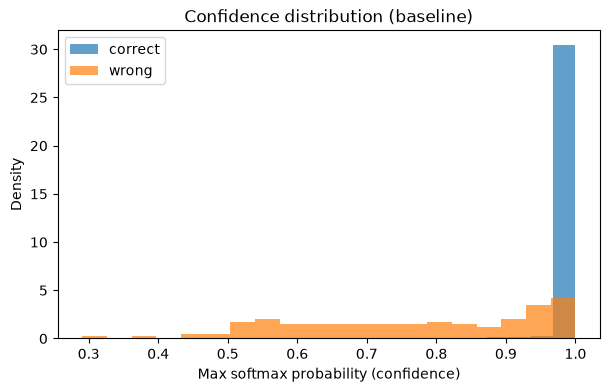

In [13]:
plt.figure(figsize=(7,4))
plt.hist(conf[correct].numpy(), bins=20, alpha=0.7, label="correct", density = True)
plt.hist(conf[~correct].numpy(), bins=20, alpha=0.7, label="wrong", density = True)
plt.xlabel("Max softmax probability (confidence)")
plt.ylabel("Density")
plt.title("Confidence distribution (baseline)")
plt.legend()
plt.show()


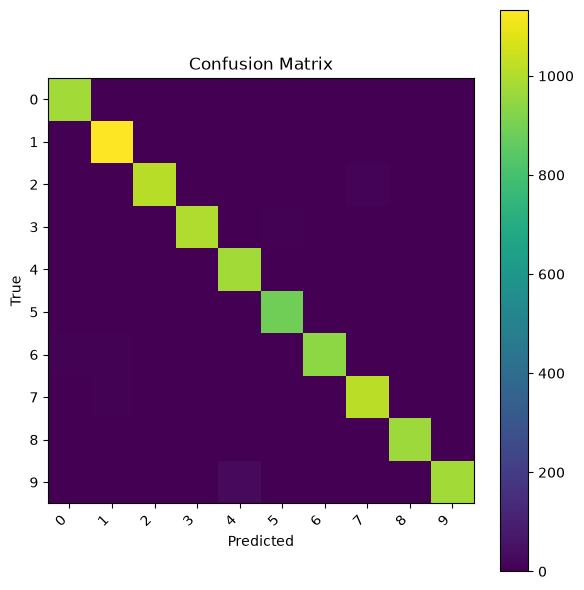

         0: 0.996
         1: 0.998
         2: 0.981
         3: 0.988
         4: 0.996
         5: 0.996
         6: 0.981
         7: 0.989
         8: 0.994
         9: 0.967


In [14]:
cm = torch.zeros(K, K, dtype=torch.int64)
for t, p in zip(y_test, pred):
    cm[int(t), int(p)] += 1

plt.figure(figsize=(6,6))
plt.imshow(cm.numpy())
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.xticks(range(K), class_names, rotation=45, ha="right")
plt.yticks(range(K), class_names)
plt.tight_layout()
plt.show()

# Per-class accuracy
per_class_acc = cm.diag().float() / cm.sum(dim=1).clamp(min=1).float()
for i, a in enumerate(per_class_acc.tolist()):
    print(f"{class_names[i]:>10s}: {a:.3f}")


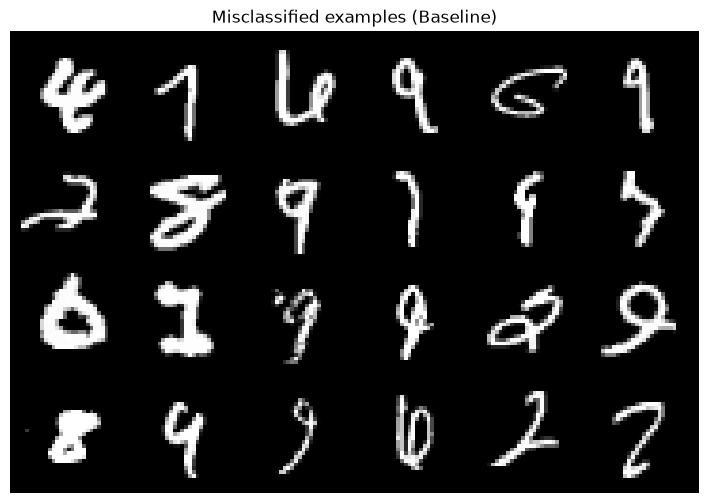

Example titles (first few):
T:4
P:8
C:0.95
T:7
P:1
C:0.88
T:6
P:4
C:0.98
T:9
P:4
C:0.59
T:6
P:5
C:0.94
T:9
P:4
C:0.91


In [15]:
# Grab a subset of misclassified examples and visualize
mis_idx = torch.where(~correct)[0]
n_show = min(24, len(mis_idx))

if n_show == 0:
    print("No misclassified samples to display.")
else:
    show_idx = mis_idx[torch.randperm(len(mis_idx))[:n_show]]

    # fetch images from testset directly (so we can re-denormalize cleanly)
    # Note: testset[i] returns transformed tensor and label; we denorm tensor.
    imgs, titles = [], []
    for i in show_idx.tolist():
        x, y = testset[i]
        imgs.append(x.unsqueeze(0))
        titles.append(f"T:{class_names[y]}\nP:{class_names[int(pred[i])]}\nC:{conf[i].item():.2f}")

    xbatch = torch.cat(imgs, dim=0).to(device)
    xvis = denorm(xbatch).cpu()

    grid = torchvision.utils.make_grid(xvis, nrow=6)
    plt.figure(figsize=(12,6))
    plt.imshow(grid.permute(1,2,0).numpy())
    plt.axis("off")
    plt.title("Misclassified examples (Baseline)")
    plt.show()

    print("Example titles (first few):")
    print("\n".join(titles[:6]))
